# **Discrete Cosine Transform (DCT)**

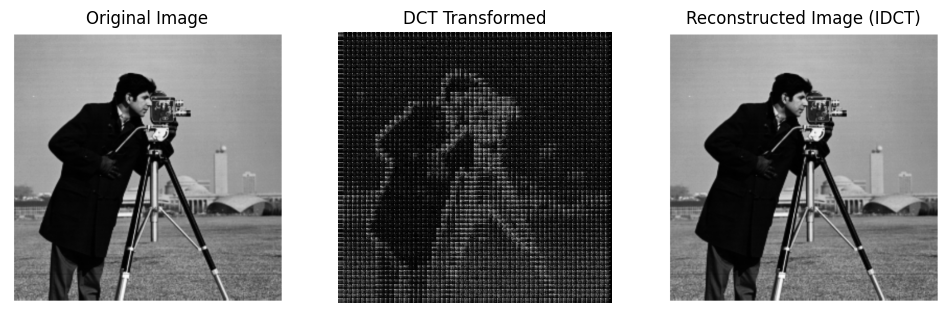

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to perform block-wise 8x8 DCT
def apply_dct(image):
    h, w = image.shape
    dct_image = np.zeros((h, w), dtype=np.float32)

    # Apply DCT to 8x8 blocks
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = image[i:i+8, j:j+8]  # Extract 8x8 block
            dct_block = cv2.dct(np.float32(block))  # Apply DCT
            dct_image[i:i+8, j:j+8] = dct_block  # Store transformed block

    return dct_image

# Function to perform block-wise 8x8 IDCT
def apply_idct(dct_image):
    h, w = dct_image.shape
    idct_image = np.zeros((h, w), dtype=np.float32)

    # Apply IDCT to 8x8 blocks
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = dct_image[i:i+8, j:j+8]  # Extract 8x8 block
            idct_block = cv2.idct(block)  # Apply Inverse DCT
            idct_image[i:i+8, j:j+8] = idct_block  # Store reconstructed block

    return idct_image

# Load the image and convert to grayscale
image = cv2.imread("thr.png", cv2.IMREAD_GRAYSCALE)

# Apply DCT and IDCT
dct_transformed = apply_dct(image)
idct_reconstructed = apply_idct(dct_transformed)

# Plot the images
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.log1p(np.abs(dct_transformed)), cmap="gray")  # Log scale for better visualization
plt.title("DCT Transformed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(idct_reconstructed, cmap="gray")
plt.title("Reconstructed Image (IDCT)")
plt.axis("off")

plt.show()